In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold'
})

WIN_COLOR  = '#2ecc71'
LOSS_COLOR = '#e74c3c'
NEUTRAL_COLOR = '#95a5a6'

PALETTE = sns.color_palette('tab10', 12)

In [2]:
df = pd.read_csv('results/sentiment_results.csv', parse_dates=['date'])   

df['outcome'] = df['W/L'].map({'W': 'Win', 'L': 'Loss', 'W-wo': 'Win', 'L-wo': 'Loss'})
df['is_win']  = df['outcome'] == 'Win'
df_sent = df[df['final_sentiment'].notna()].copy()

TEAMS = sorted(df['team'].dropna().unique().tolist())
TEAM_COLOR = {team: PALETTE[i % len(PALETTE)] for i, team in enumerate(TEAMS)}

print(f"Teams ({len(TEAMS)}): {TEAMS}")
print(f"Total posts: {len(df):}")
print(f"Date range: {df['date'].min().date()} - {df['date'].max().date()}")
print()
print(df.groupby('team')[['final_sentiment','win']].agg({'final_sentiment':'count','win':'mean'}).rename(columns={'final_sentiment':'posts','win':'win_rate'}).round(3))

Teams (8): ['CHW', 'COL', 'MIL', 'MIN', 'NYY', 'PHI', 'TOR', 'WSN']
Total posts: 380814
Date range: 2025-03-20 - 2025-10-04

      posts  win_rate
team                 
CHW   47485     0.391
COL   48516     0.304
MIL   46391     0.583
MIN   47945     0.405
NYY   47869     0.581
PHI   47345     0.569
TOR   46961     0.607
WSN   48302     0.389


In [3]:
def compute_streak(series):
    out = []; current = 0; prev = None
    for v in series:
        current = (current + 1 if v == 1 else current - 1) if v == prev else (1 if v == 1 else -1)
        out.append(current); prev = v
    return out

game_frames = []
for team in TEAMS:
    tdf = df_sent[(df_sent['team'] == team) & df_sent['outcome'].notna()]
    if tdf.empty:
        continue
    g = (
        tdf.groupby(['team', 'date', 'outcome', 'is_win', 'run_diff', 'home'])
        .agg(mean_sentiment=('final_sentiment', 'mean'),
             median_sentiment=('final_sentiment', 'median'),
             post_count=('final_sentiment', 'count'),
             sentiment_std=('final_sentiment', 'std'))
        .reset_index().sort_values('date')
    )
    g['win_int']            = g['is_win'].astype(int)
    g['win_pct_rolling5']   = g['win_int'].rolling(5, min_periods=1).mean()
    g['win_pct_cumulative'] = g['win_int'].expanding().mean()
    g['streak']             = compute_streak(g['win_int'].tolist())
    game_frames.append(g)

game_df = pd.concat(game_frames, ignore_index=True)

print(f"Game-day rows total: {len(game_df):,}")
print(game_df.groupby('team')[['is_win','mean_sentiment']].agg({'is_win': ['sum', 'count'], 'mean_sentiment': 'mean'}).round(3))

Game-day rows total: 1,296
     is_win       mean_sentiment
        sum count           mean
team                            
CHW      60   162          0.090
COL      43   162          0.098
MIL      97   162          0.090
MIN      70   162          0.076
NYY      94   162          0.065
PHI      96   162          0.064
TOR      94   162          0.084
WSN      66   162          0.090


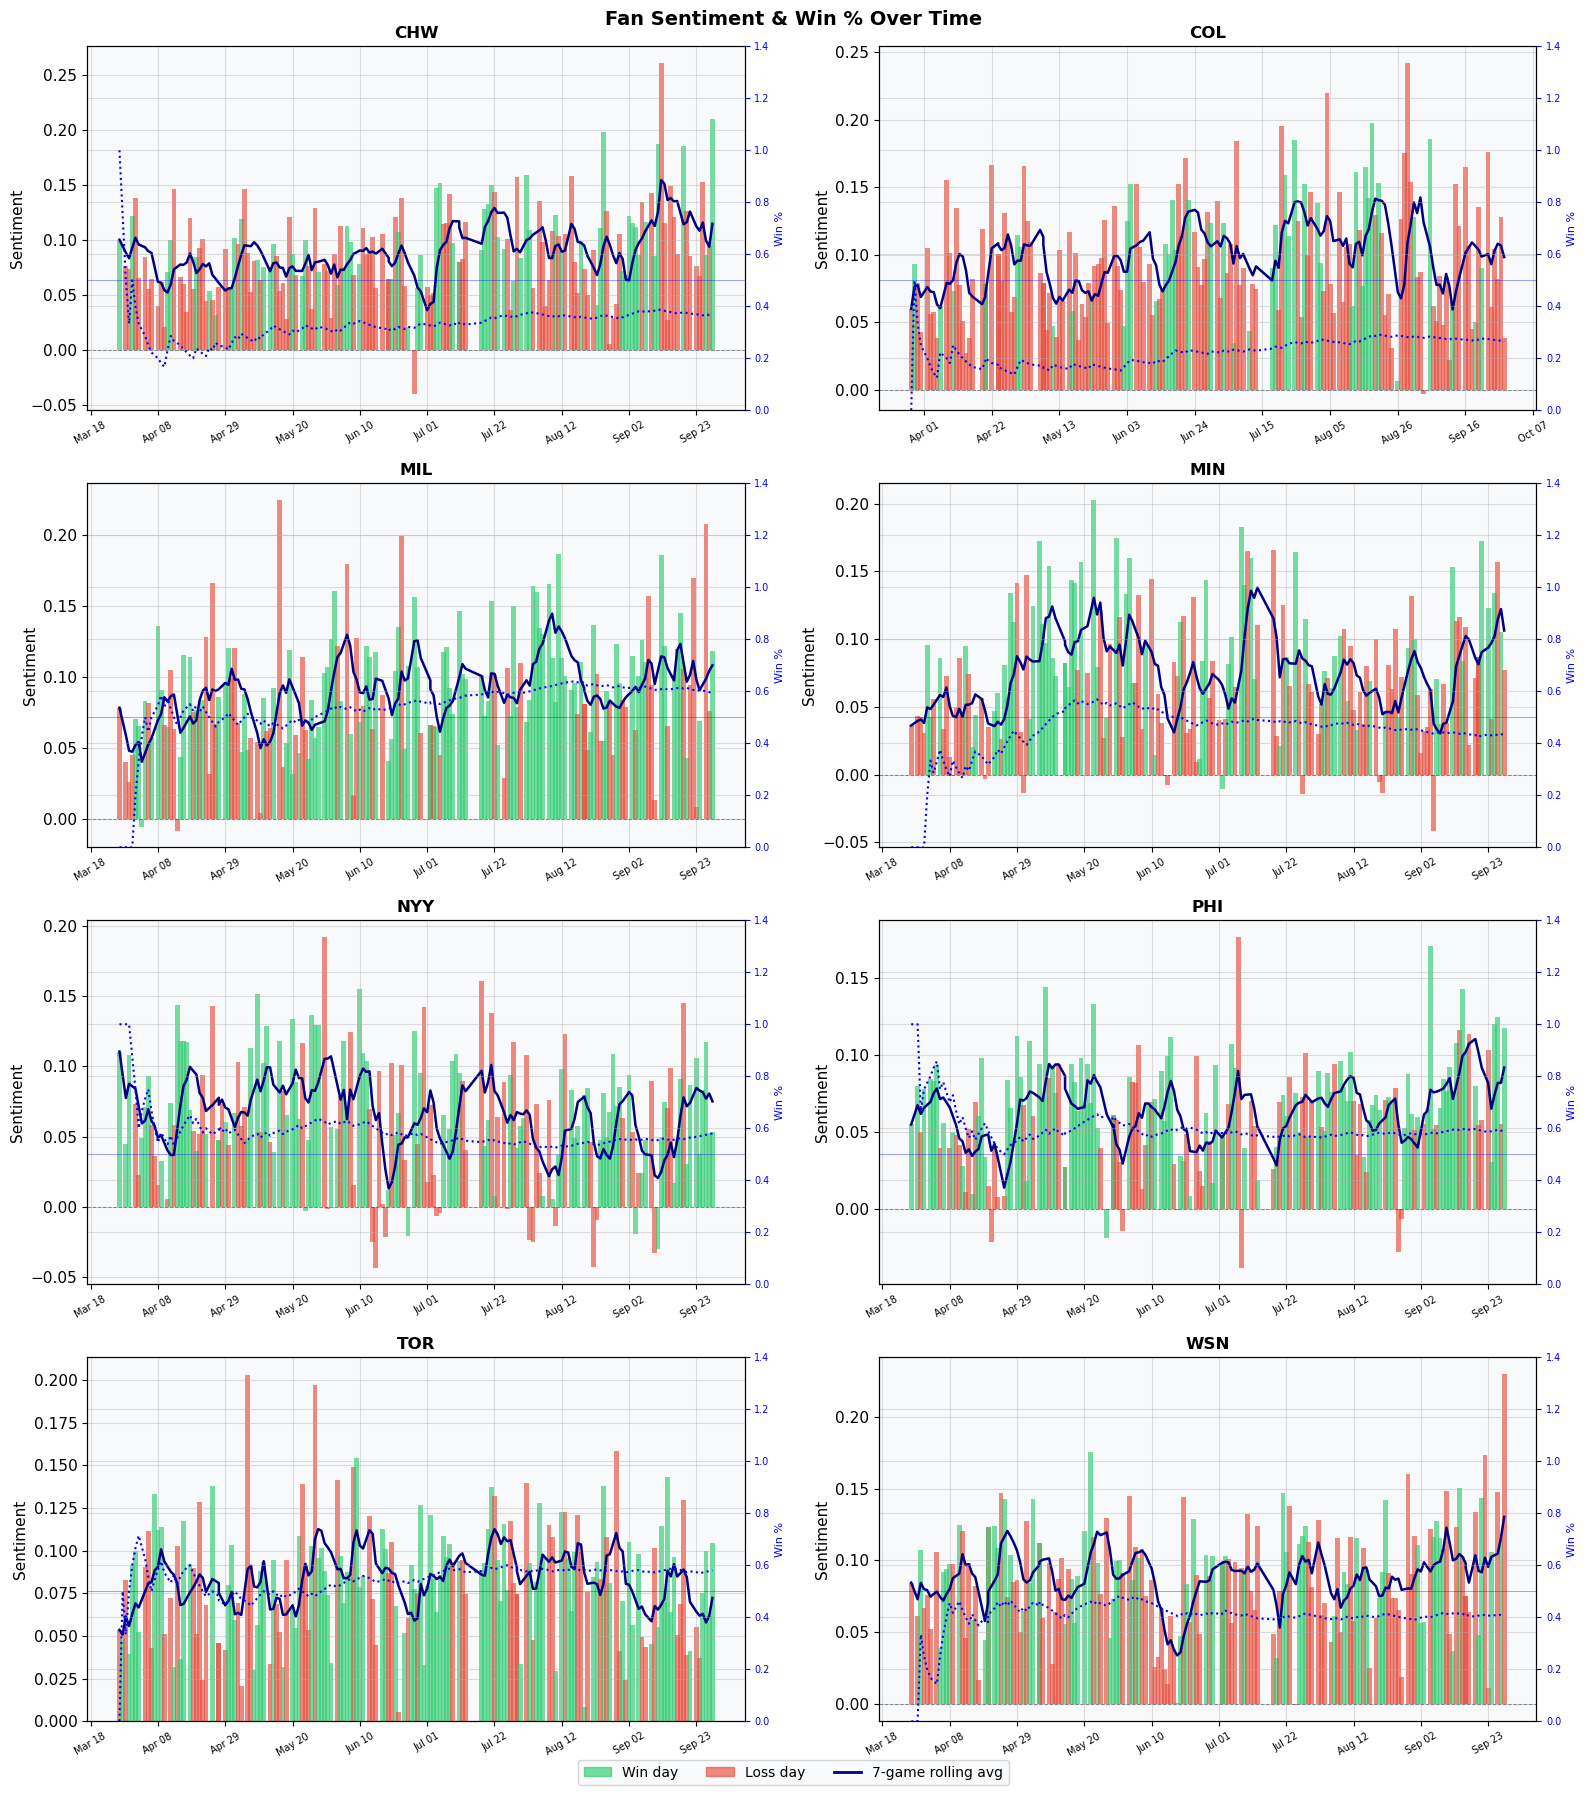

In [4]:
n = len(TEAMS)
ncols = 2
nrows = (n + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.5 * nrows), sharex=False)
axes = axes.flatten()

for ax in axes[n:]:   
    ax.set_visible(False)

for i, team in enumerate(TEAMS):
    ax = axes[i]
    tg = game_df[game_df['team'] == team].sort_values('date')
    if tg.empty:
        ax.set_title(f'{team} — no data'); continue

    for _, row in tg.iterrows():
        ax.bar(row['date'], row['mean_sentiment'],
               color=WIN_COLOR if row['is_win'] else LOSS_COLOR, alpha=0.65, width=1.5)

    roll = tg.set_index('date')['mean_sentiment'].rolling('7D').mean()
    ax.plot(roll.index, roll.values, color='navy', linewidth=1.8, label='7-game avg')
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)

    ax2 = ax.twinx()
    ax2.plot(tg['date'], tg['win_pct_cumulative'], color='blue',
             linewidth=1.5, linestyle=':', label='Cum win %')
    ax2.set_ylim(0, 1.4)
    ax2.set_ylabel('Win %', fontsize=8, color='blue')
    ax2.tick_params(axis='y', labelsize=7, colors='blue')
    ax2.axhline(0.5, color='blue', linewidth=0.5, alpha=0.5)

    ax.set_title(f'{team}')
    ax.set_ylabel('Sentiment')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, fontsize=7)

win_p  = mpatches.Patch(color=WIN_COLOR,  alpha=0.65, label='Win day')
loss_p = mpatches.Patch(color=LOSS_COLOR, alpha=0.65, label='Loss day')
avg_l  = plt.Line2D([0],[0], color='navy', linewidth=2, label='7-game rolling avg')
fig.legend(handles=[win_p, loss_p, avg_l], loc='lower center',
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.suptitle('Fan Sentiment & Win % Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_sentiment_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

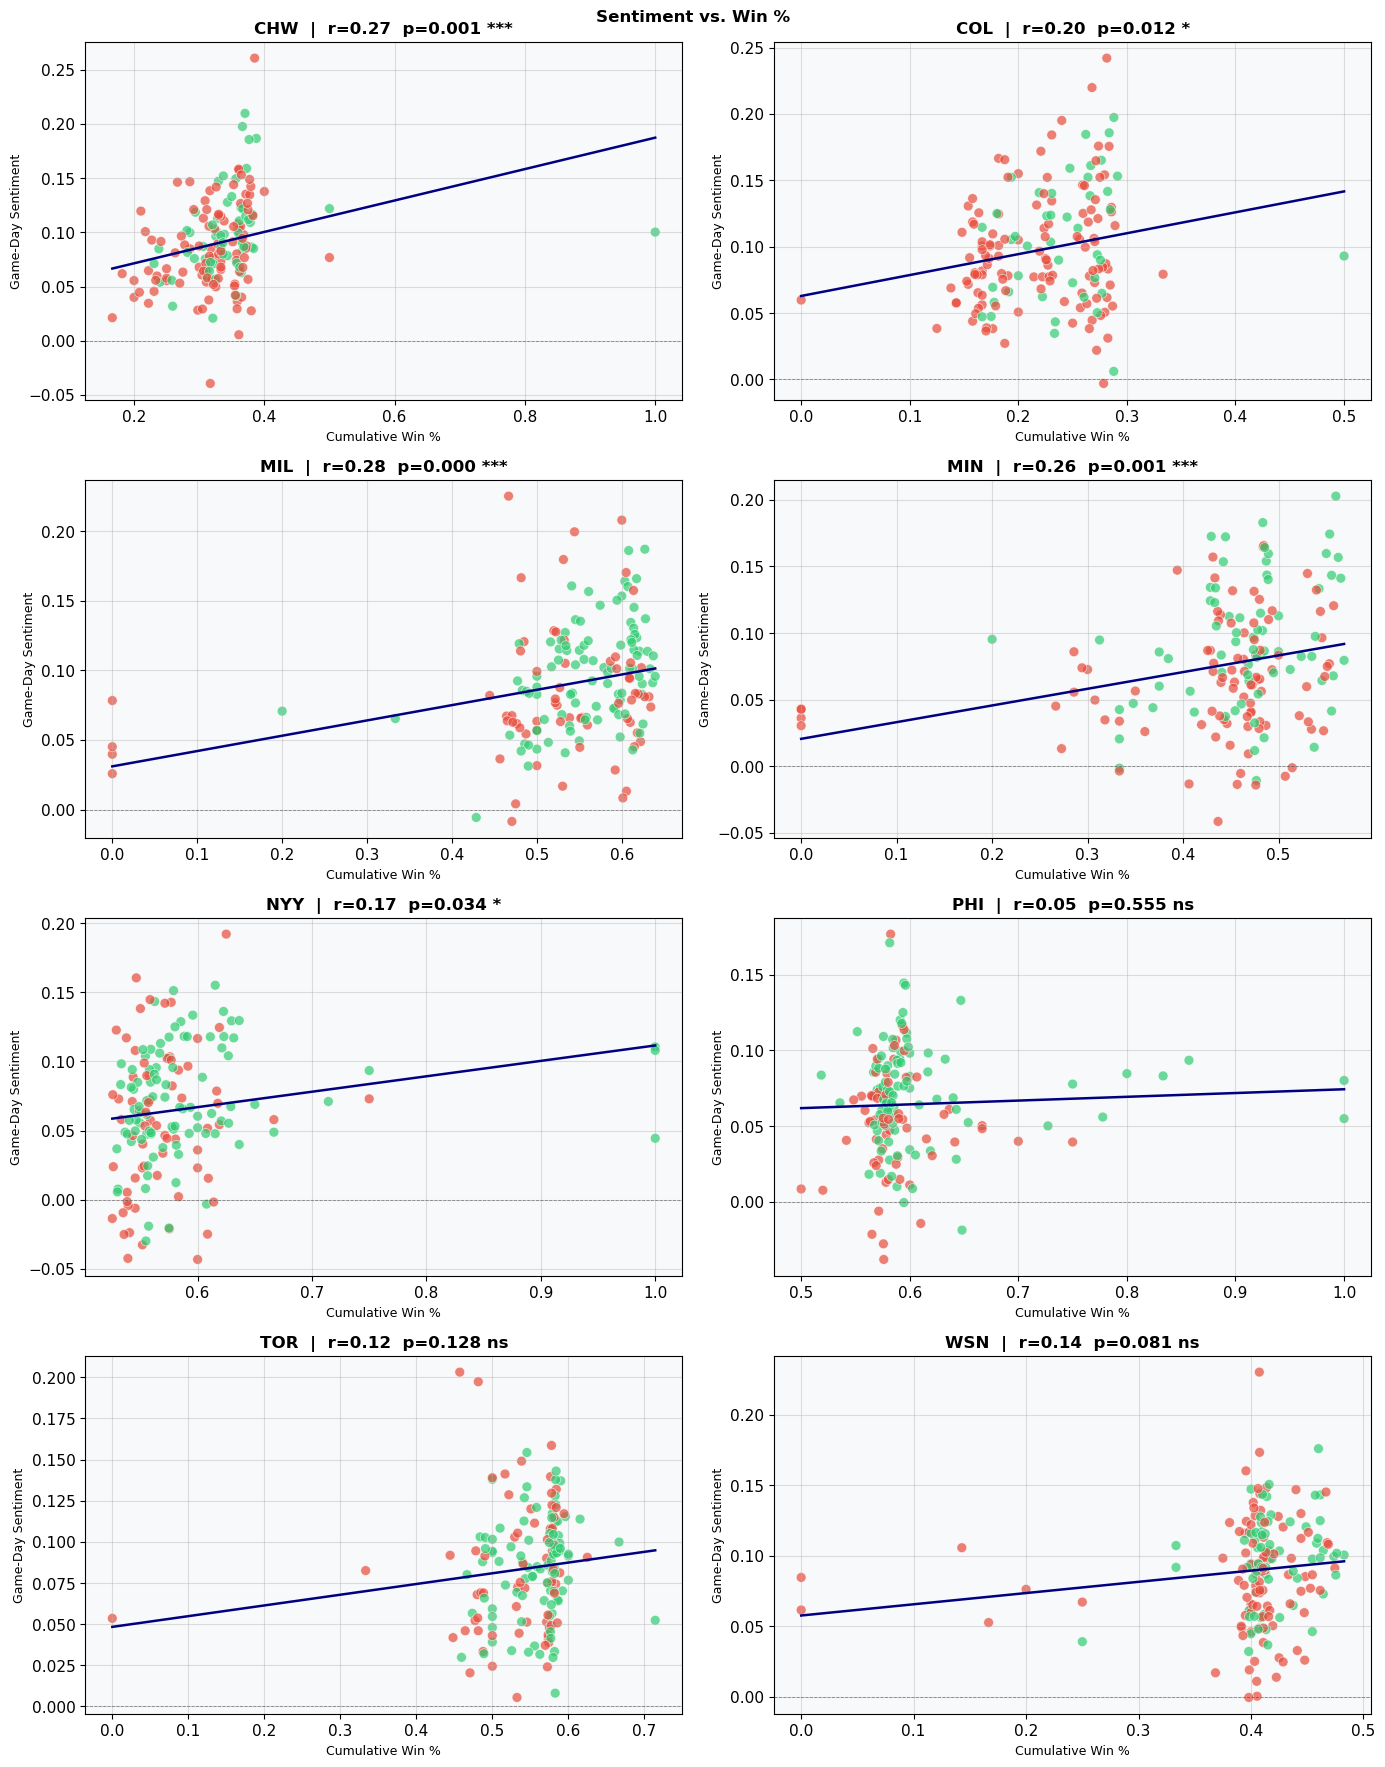

In [20]:
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
axes = axes.flatten()
for ax in axes[n:]: ax.set_visible(False)

for i, team in enumerate(TEAMS):
    ax = axes[i]
    tg = game_df[game_df['team'] == team]
    mask = tg[['win_pct_cumulative', 'mean_sentiment']].notna().all(axis=1)
    x = tg.loc[mask, 'win_pct_cumulative']
    y = tg.loc[mask, 'mean_sentiment']
    if len(x) < 5:
        ax.set_title(f'{team} — insufficient data'); continue

    colors = [WIN_COLOR if w else LOSS_COLOR for w in tg.loc[mask, 'is_win']]
    ax.scatter(x, y, c=colors, alpha=0.7, s=50, edgecolors='white', linewidths=0.5)

    sl, ic, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, sl * xline + ic, color='navy', linewidth=1.8)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.4)

    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_title(f'{team}  |  r={r:.2f}  p={p:.3f} {sig}')
    ax.set_xlabel('Cumulative Win %', fontsize=9)
    ax.set_ylabel('Game-Day Sentiment', fontsize=9)

plt.suptitle('Sentiment vs. Win %', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_sentiment_vs_winpct.png', dpi=150, bbox_inches='tight')
plt.show()

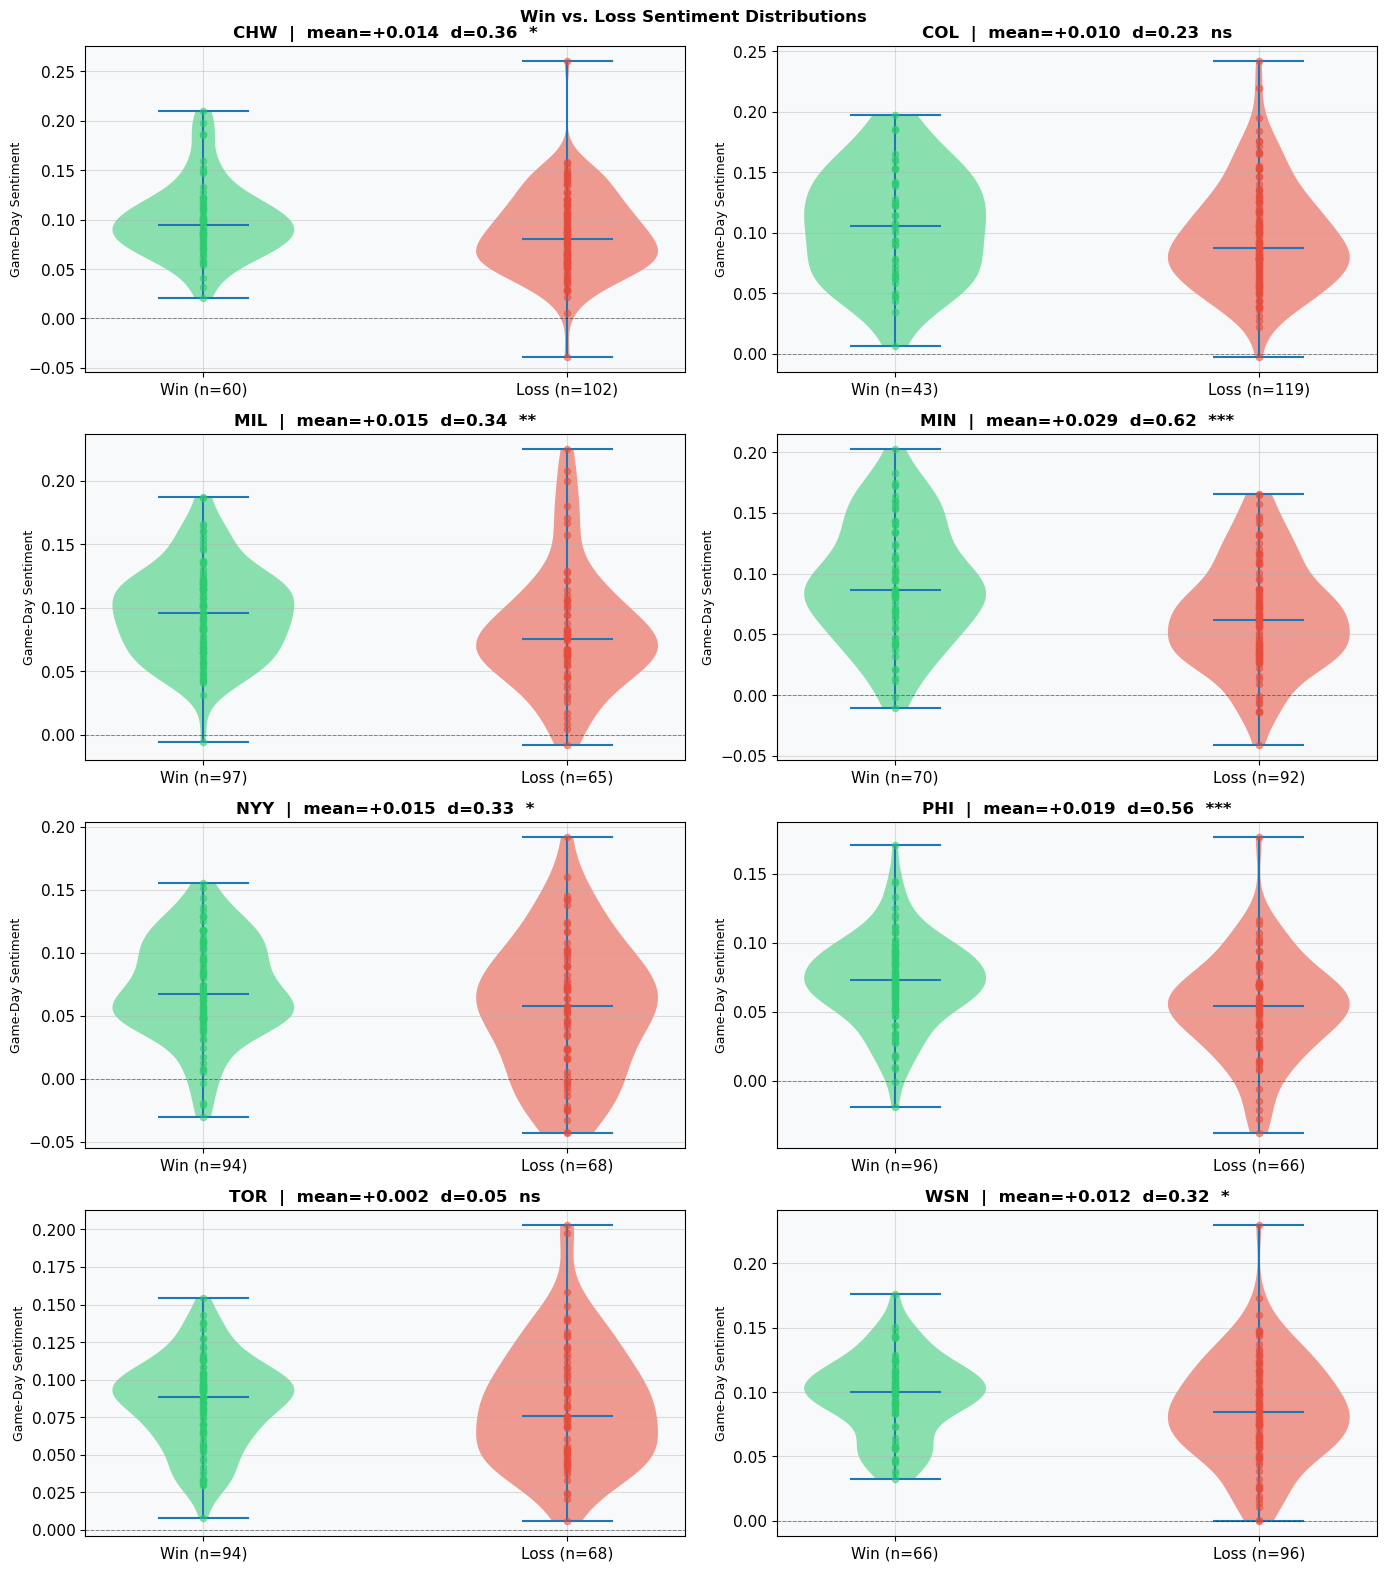

In [23]:
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()
for ax in axes[n:]: ax.set_visible(False)

for i, team in enumerate(TEAMS):
    ax = axes[i]
    tg = game_df[game_df['team'] == team]
    wins = tg.loc[tg['is_win'],  'mean_sentiment'].dropna()
    losses = tg.loc[~tg['is_win'], 'mean_sentiment'].dropna()
    if len(wins) < 3 or len(losses) < 3:
        ax.set_title(f'{team} — insufficient data'); continue

    parts = ax.violinplot([wins, losses], positions=[1, 2],
                          showmedians=True, showmeans=False)
    for j, pc in enumerate(parts['bodies']):
        pc.set_facecolor([WIN_COLOR, LOSS_COLOR][j]); pc.set_alpha(0.55)
    ax.scatter([1]*len(wins),  wins,   color=WIN_COLOR,  alpha=0.5, s=20, zorder=3)
    ax.scatter([2]*len(losses), losses, color=LOSS_COLOR, alpha=0.5, s=20, zorder=3)
    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'Win (n={len(wins)})', f'Loss (n={len(losses)})'])
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)

    _, up = mannwhitneyu(wins, losses, alternative='two-sided')
    d = (wins.mean() - losses.mean()) / np.sqrt((wins.std()**2 + losses.std()**2) / 2)
    sig = '***' if up < 0.001 else '**' if up < 0.01 else '*' if up < 0.05 else 'ns'
    ax.set_title(f'{team}  |  mean={wins.mean()-losses.mean():+.3f}  d={d:.2f}  {sig}')
    ax.set_ylabel('Game-Day Sentiment', fontsize=9)

plt.suptitle('Win vs. Loss Sentiment Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_wins_vs_losses.png', dpi=150, bbox_inches='tight')
plt.show()

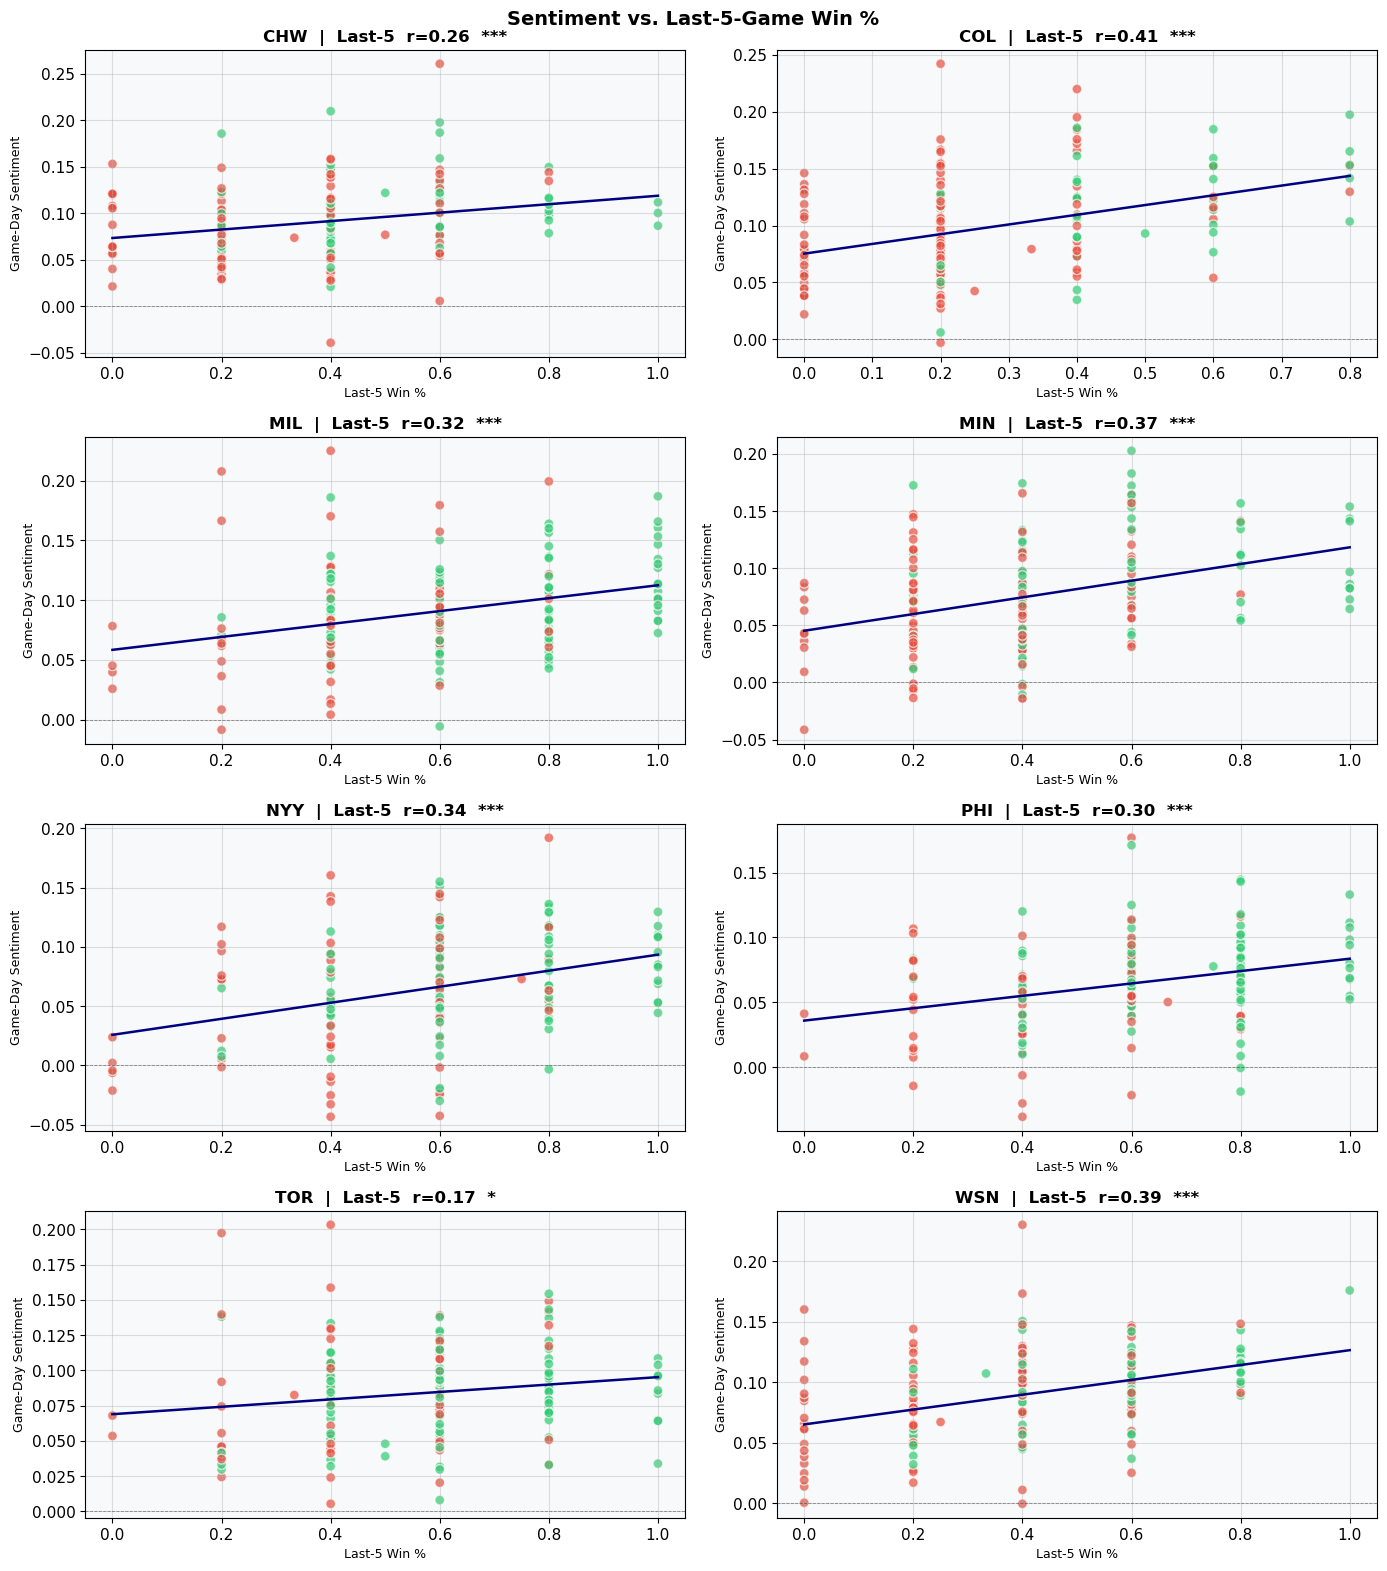

In [25]:
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()
for ax in axes[n:]: ax.set_visible(False)

for i, team in enumerate(TEAMS):
    ax = axes[i]
    tg = game_df[game_df['team'] == team]
    mask5 = tg[['win_pct_rolling5','mean_sentiment']].notna().all(axis=1)
    x5 = tg.loc[mask5, 'win_pct_rolling5']
    y5 = tg.loc[mask5, 'mean_sentiment']
    if len(x5) < 5:
        ax.set_title(f'{team} — insufficient data'); continue

    colors5 = [WIN_COLOR if w else LOSS_COLOR for w in tg.loc[mask5, 'is_win']]
    ax.scatter(x5, y5, c=colors5, alpha=0.7, s=50, edgecolors='white')
    sl5, ic5, r5, p5, _ = stats.linregress(x5, y5)
    xline = np.linspace(x5.min(), x5.max(), 100)
    ax.plot(xline, sl5 * xline + ic5, color='navy', linewidth=1.8)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.4)

    sig = '***' if p5 < 0.001 else '**' if p5 < 0.01 else '*' if p5 < 0.05 else 'ns'
    ax.set_title(f'{team}  |  Last-5  r={r5:.2f}  {sig}')
    ax.set_xlabel('Last-5 Win %', fontsize=9)
    ax.set_ylabel('Game-Day Sentiment', fontsize=9)

plt.suptitle('Sentiment vs. Last-5-Game Win %', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_recent_performance.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
regression_results = []

for team in TEAMS:
    tg = game_df[game_df['team'] == team]
    model_df = tg[['mean_sentiment','win_int','run_diff','win_pct_rolling5','streak']].dropna()
    if len(model_df) < 10:
        print(f'{team}: too few games ({len(model_df)}) — skipping regression')
        continue

    X  = model_df[['win_int','run_diff','win_pct_rolling5','streak']]
    yy = model_df['mean_sentiment']
    X_scaled = StandardScaler().fit_transform(X)
    reg = LinearRegression().fit(X_scaled, yy)
    y_pred = reg.predict(X_scaled)
    r2 = r2_score(yy, y_pred)
    residuals = yy - y_pred

    corr_rows = []
    for feat, col in [('Cumul. Win%','win_pct_cumulative'),('Last-5','win_pct_rolling5'),
                      ('Streak','streak'),('Run Diff','run_diff')]:
        mask = tg[['mean_sentiment',col]].notna().all(axis=1)
        if mask.sum() < 5: continue
        _, _, rc, pc, _ = stats.linregress(tg.loc[mask, col], tg.loc[mask,'mean_sentiment'])
        corr_rows.append({'predictor': feat, 'r': rc, 'p': pc})

    wins  = tg.loc[tg['is_win'],  'mean_sentiment'].dropna()
    losses = tg.loc[~tg['is_win'], 'mean_sentiment'].dropna()
    sentiment_gap = wins.mean() - losses.mean() if len(wins) > 0 and len(losses) > 0 else np.nan
    _, mwu_p = mannwhitneyu(wins, losses, alternative='two-sided') if len(wins) > 2 and len(losses) > 2 else (np.nan, np.nan)

    regression_results.append({
        'team': team,
        'n_games': len(model_df),
        'r2': r2,
        'unexplained_pct': (1 - r2) * 100,
        'sentiment_gap': sentiment_gap,
        'mwu_p': mwu_p,
        'win_mean': wins.mean() if len(wins) > 0 else np.nan,
        'loss_mean': losses.mean() if len(losses) > 0 else np.nan,
        'residual_std': residuals.std(),
        'coefs': dict(zip(['win_int','run_diff','win_pct_rolling5','streak'], reg.coef_)),
        'corrs': corr_rows
    })

results_df = pd.DataFrame(regression_results)
display_cols = ['team','n_games','r2','unexplained_pct','sentiment_gap','mwu_p','win_mean','loss_mean']
print(results_df[display_cols].round(3).to_string(index=False))

team  n_games    r2  unexplained_pct  sentiment_gap  mwu_p  win_mean  loss_mean
 CHW      162 0.087           91.277          0.014  0.029     0.099      0.085
 COL      162 0.174           82.575          0.010  0.166     0.106      0.096
 MIL      162 0.122           87.838          0.015  0.004     0.096      0.082
 MIN      162 0.156           84.389          0.029  0.000     0.093      0.064
 NYY      162 0.168           83.164          0.015  0.048     0.072      0.056
 PHI      162 0.153           84.713          0.019  0.000     0.072      0.053
 TOR      162 0.034           96.615          0.002  0.377     0.085      0.083
 WSN      162 0.198           80.162          0.012  0.038     0.097      0.085


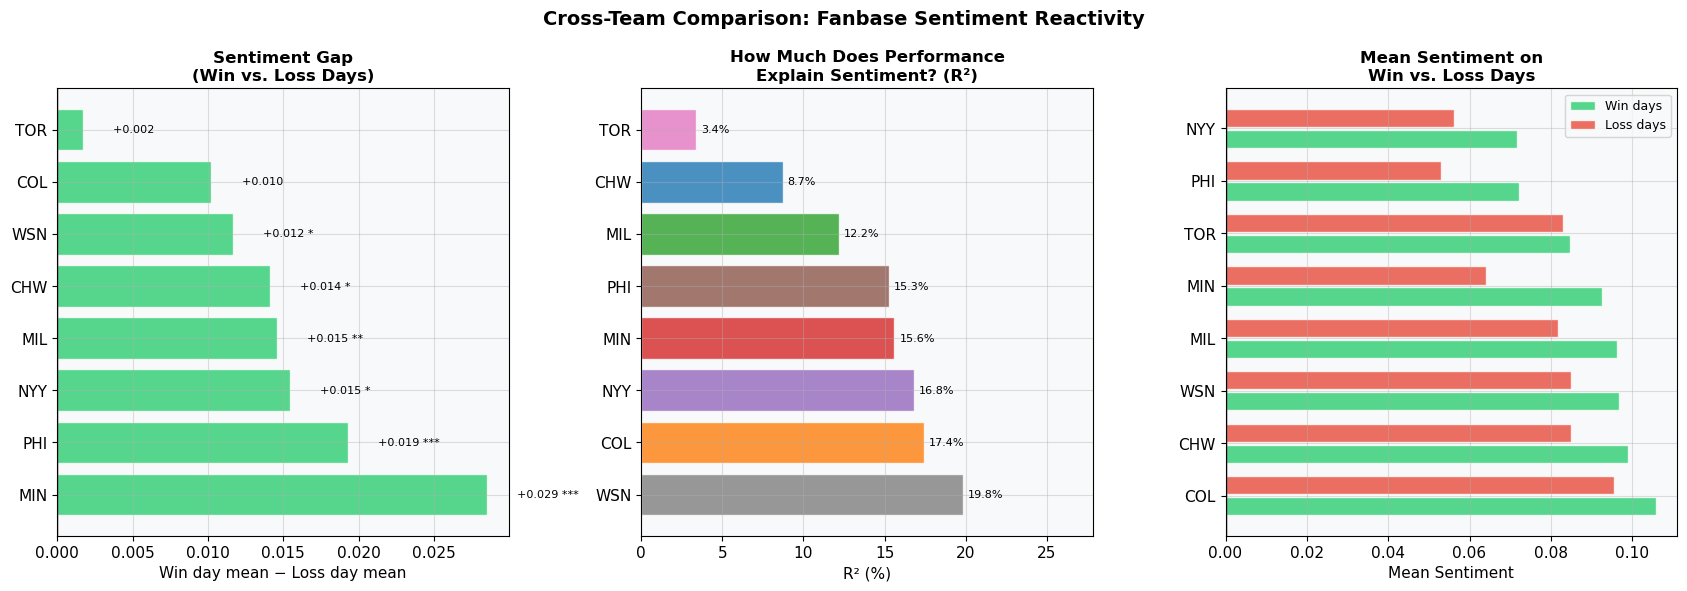

In [27]:
plot_df = results_df.sort_values('sentiment_gap', ascending=False).dropna(subset=['sentiment_gap'])

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

ax = axes[0]
colors_bar = [WIN_COLOR if g > 0 else LOSS_COLOR for g in plot_df['sentiment_gap']]
bars = ax.barh(plot_df['team'], plot_df['sentiment_gap'], color=colors_bar, alpha=0.8, edgecolor='white')
for bar, (_, row) in zip(bars, plot_df.iterrows()):
    sig = '***' if row['mwu_p'] < 0.001 else '**' if row['mwu_p'] < 0.01 else '*' if row['mwu_p'] < 0.05 else ''
    x_pos = bar.get_width()
    ax.text(x_pos + 0.002 if x_pos >= 0 else x_pos - 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{x_pos:+.3f} {sig}', va='center',
            ha='left' if x_pos >= 0 else 'right', fontsize=8)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Win day mean − Loss day mean')
ax.set_title('Sentiment Gap\n(Win vs. Loss Days)')

ax2 = axes[1]
r2_df = results_df.sort_values('r2', ascending=False).dropna(subset=['r2'])
bar_colors_r2 = [TEAM_COLOR[t] for t in r2_df['team']]
bars2 = ax2.barh(r2_df['team'], r2_df['r2'] * 100, color=bar_colors_r2, alpha=0.8, edgecolor='white')
for bar, (_, row) in zip(bars2, r2_df.iterrows()):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{row['r2']*100:.1f}%", va='center', fontsize=8)
ax2.set_xlabel('R² (%)')
ax2.set_title('How Much Does Performance\nExplain Sentiment? (R²)')
ax2.set_xlim(0, max(r2_df['r2'] * 100) + 8)

ax3 = axes[2]
wl_df = results_df.dropna(subset=['win_mean','loss_mean']).sort_values('win_mean', ascending=False)
y_pos = np.arange(len(wl_df))
ax3.barh(y_pos - 0.2, wl_df['win_mean'],  0.35, color=WIN_COLOR,  alpha=0.8, label='Win days',  edgecolor='white')
ax3.barh(y_pos + 0.2, wl_df['loss_mean'], 0.35, color=LOSS_COLOR, alpha=0.8, label='Loss days', edgecolor='white')
ax3.set_yticks(y_pos)
ax3.set_yticklabels(wl_df['team'])
ax3.axvline(0, color='black', linewidth=1)
ax3.set_xlabel('Mean Sentiment')
ax3.set_title('Mean Sentiment on\nWin vs. Loss Days')
ax3.legend(fontsize=9)

plt.suptitle('Cross-Team Comparison: Fanbase Sentiment Reactivity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6a_cross_team_reactivity.png', dpi=150, bbox_inches='tight')
plt.show()

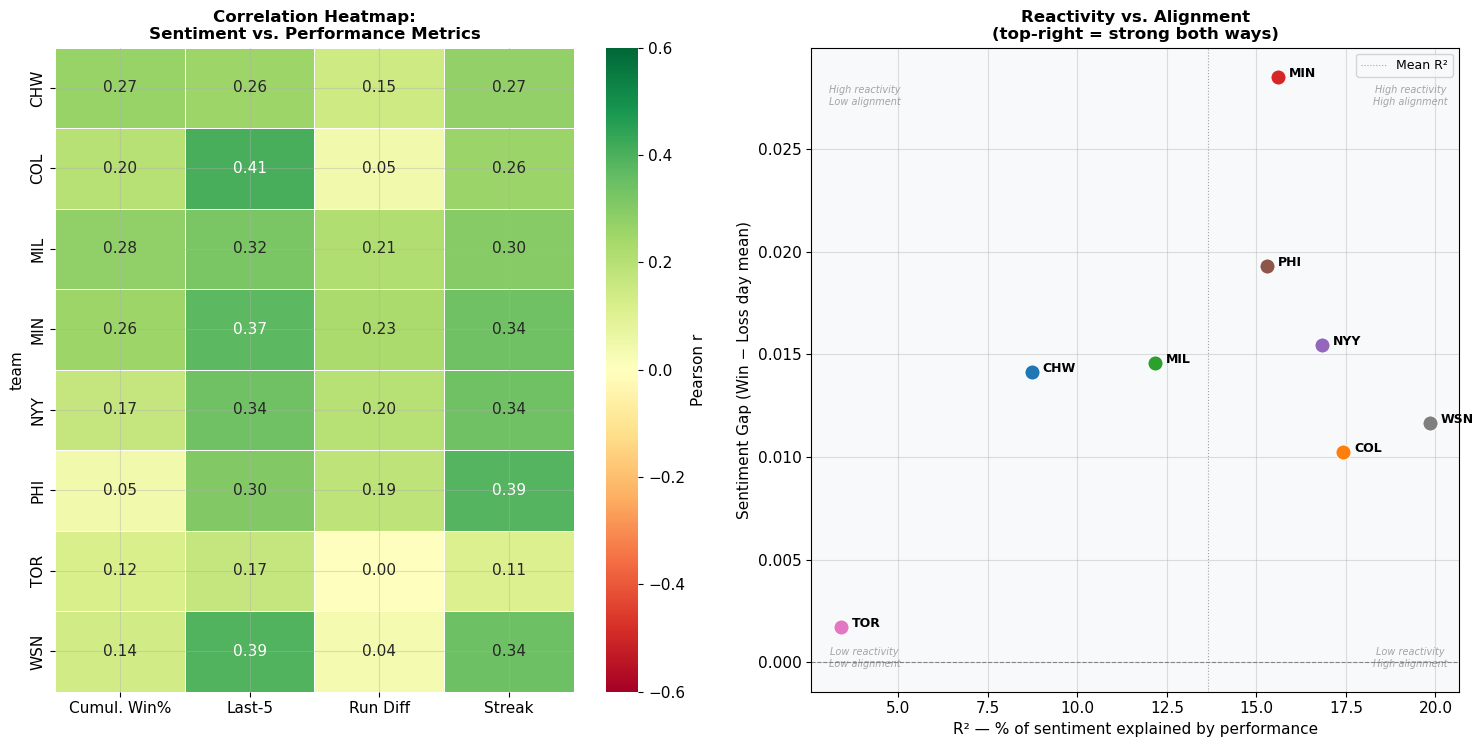

In [13]:
corr_records = []
for row in regression_results:
    for c in row['corrs']:
        corr_records.append({'team': row['team'], 'predictor': c['predictor'], 'r': c['r'], 'p': c['p']})

corr_long = pd.DataFrame(corr_records)
corr_pivot = corr_long.pivot(index='team', columns='predictor', values='r')

fig, axes = plt.subplots(1, 2, figsize=(15, max(5, len(TEAMS) * 0.7 + 2)))

ax = axes[0]
sns.heatmap(corr_pivot, ax=ax, cmap='RdYlGn', center=0, vmin=-0.6, vmax=0.6,
            annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation Heatmap:\nSentiment vs. Performance Metrics')
ax.set_xlabel('')

ax2 = axes[1]
plot_d = results_df.dropna(subset=['sentiment_gap','r2'])
for _, row in plot_d.iterrows():
    ax2.scatter(row['r2'] * 100, row['sentiment_gap'],
                color=TEAM_COLOR[row['team']], s=120, zorder=3,
                edgecolors='white', linewidths=0.8)
    ax2.annotate(row['team'],
                 (row['r2'] * 100 + 0.3, row['sentiment_gap']),
                 fontsize=9, fontweight='bold')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax2.axvline(plot_d['r2'].mean() * 100, color='gray', linewidth=0.8,
            linestyle=':', alpha=0.7, label='Mean R²')
ax2.set_xlabel('R² — % of sentiment explained by performance')
ax2.set_ylabel('Sentiment Gap (Win − Loss day mean)')
ax2.set_title('Reactivity vs. Alignment\n(top-right = strong both ways)')
ax2.legend(fontsize=9)

xlim = ax2.get_xlim(); ylim = ax2.get_ylim()
xmid = (xlim[0] + xlim[1]) / 2; ymid = (ylim[0] + ylim[1]) / 2
for txt, xp, yp in [('High reactivity\nLow alignment', xlim[0]*0.9+xmid*0.15, ylim[1]*0.85+ymid*0.15),
                    ('High reactivity\nHigh alignment', xlim[1]*0.85+xmid*0.15, ylim[1]*0.85+ymid*0.15),
                    ('Low reactivity\nLow alignment',  xlim[0]*0.9+xmid*0.15, ylim[0]*0.85+ymid*0.1),
                    ('Low reactivity\nHigh alignment', xlim[1]*0.85+xmid*0.15, ylim[0]*0.85+ymid*0.1)]:
    ax2.text(xp, yp, txt, fontsize=7, color='gray', ha='center', va='center',
             style='italic', alpha=0.7)

plt.tight_layout()
plt.savefig('fig6b_alignment_vs_reactivity.png', dpi=150, bbox_inches='tight')
plt.show()

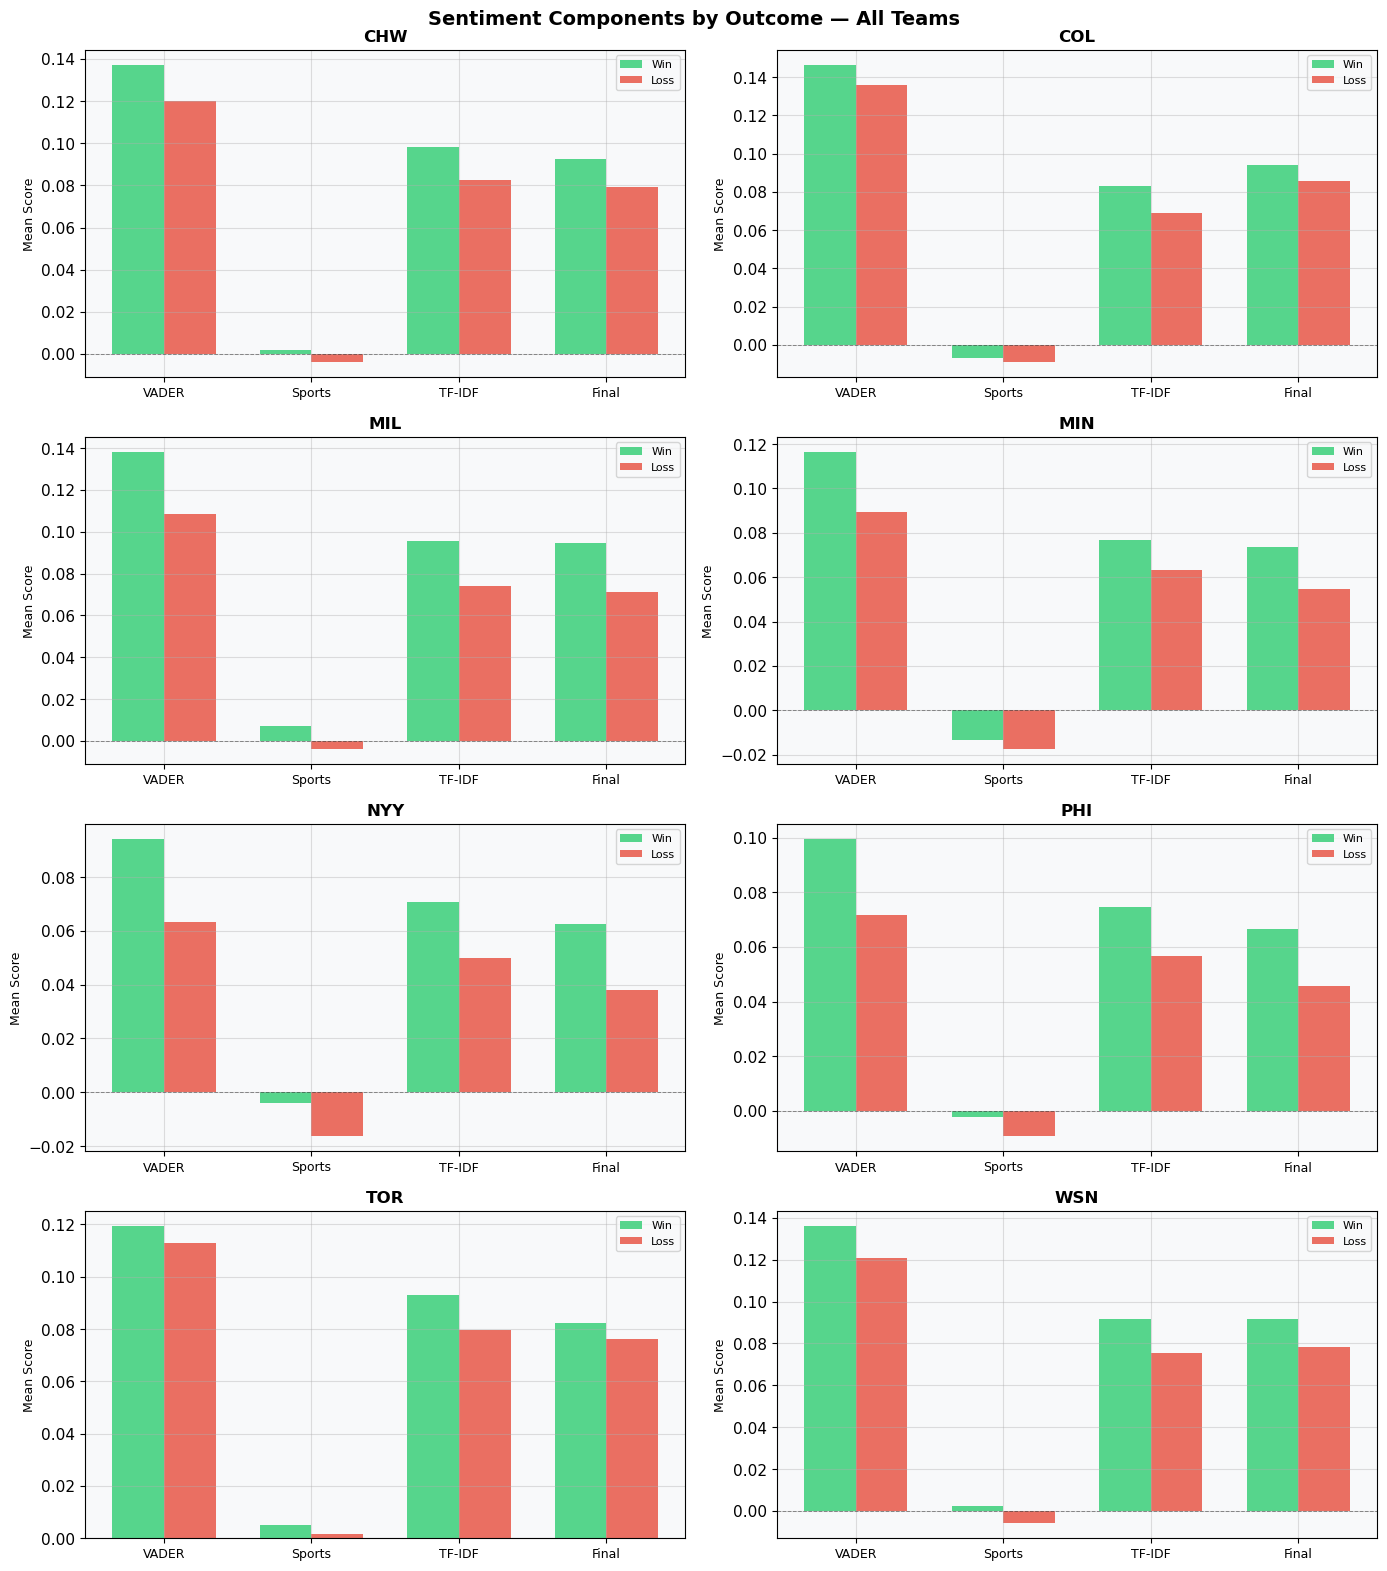

In [30]:
components = ['vader_sentiment', 'sports_sentiment', 'tfidf_context', 'final_sentiment']
comp_labels = ['VADER', 'Sports', 'TF-IDF', 'Final']

comp_df = df_sent[df_sent['outcome'].notna()][['team','outcome'] + components]
comp_means = comp_df.groupby(['team','outcome'])[components].mean().reset_index()

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()
for ax in axes[n:]: ax.set_visible(False)

x = np.arange(len(components)); width = 0.35

for i, team in enumerate(TEAMS):
    ax = axes[i]
    wins_row = comp_means[(comp_means['team']==team) & (comp_means['outcome']=='Win')]
    loss_row = comp_means[(comp_means['team']==team) & (comp_means['outcome']=='Loss')]
    if wins_row.empty or loss_row.empty:
        ax.set_title(f'{team} — insufficient data'); continue

    ax.bar(x - width/2, wins_row[components].values[0], width, label='Win',  color=WIN_COLOR,  alpha=0.8)
    ax.bar(x + width/2, loss_row[components].values[0], width, label='Loss', color=LOSS_COLOR, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(comp_labels, fontsize=9)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_title(f'{team}')
    ax.set_ylabel('Mean Score', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Sentiment Components by Outcome — All Teams', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_components.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
print("=" * 70)
print("FINAL STATISTICAL SUMMARY: ALL TEAMS")
print("=" * 70)

for _, row in results_df.sort_values('sentiment_gap', ascending=False).iterrows():
    sig = '***' if row['mwu_p'] < 0.001 else '**' if row['mwu_p'] < 0.01 else '*' if row['mwu_p'] < 0.05 else 'ns'
    print(f"\n{'─'*40}")
    print(f"  Team:              {row['team']}")
    print(f"  Games analyzed:    {int(row['n_games'])}")
    print(f"  Win day mean:      {row['win_mean']:+.4f}")
    print(f"  Loss day mean:     {row['loss_mean']:+.4f}")
    print(f"  Sentiment gap:     {row['sentiment_gap']:+.4f}  ({sig})")
    print(f"  R² (performance):  {row['r2']:.3f}  ({row['r2']*100:.1f}% explained)")
    print(f"  Unexplained:       {row['unexplained_pct']:.1f}%")
    print(f"  Correlations:")
    for c in row['corrs']:
        star = '***' if c['p']<0.001 else '**' if c['p']<0.01 else '*' if c['p']<0.05 else ''
        print(f"    {c['predictor']:15s}: r={c['r']:+.3f}  p={c['p']:.4f} {star}")

print(f"\n{'='*70}")
print("CROSS-TEAM HIGHLIGHTS")
print(f"{'='*70}")
top_react = results_df.loc[results_df['sentiment_gap'].idxmax(), 'team']
top_align = results_df.loc[results_df['r2'].idxmax(), 'team']
least_align = results_df.loc[results_df['r2'].idxmin(), 'team']
print(f"  Most reactive fanbase:        {top_react}  (largest win/loss sentiment gap)")
print(f"  Strongest performance align:  {top_align}  (highest R²)")
print(f"  Most sentiment-independent:   {least_align}  (lowest R², sentiment driven by other factors)")
print(f"  Average R² across teams:      {results_df['r2'].mean():.3f}")
print(f"  Average unexplained var:      {results_df['unexplained_pct'].mean():.1f}%")

FINAL STATISTICAL SUMMARY: ALL TEAMS

────────────────────────────────────────
  Team:              MIN
  Games analyzed:    162
  Win day mean:      +0.0926
  Loss day mean:     +0.0641
  Sentiment gap:     +0.0285  (***)
  R² (performance):  0.156  (15.6% explained)
  Unexplained:       84.4%
  Correlations:
    Cumul. Win%    : r=+0.258  p=0.0009 ***
    Last-5         : r=+0.371  p=0.0000 ***
    Streak         : r=+0.340  p=0.0000 ***
    Run Diff       : r=+0.228  p=0.0035 **

────────────────────────────────────────
  Team:              PHI
  Games analyzed:    162
  Win day mean:      +0.0722
  Loss day mean:     +0.0529
  Sentiment gap:     +0.0193  (***)
  R² (performance):  0.153  (15.3% explained)
  Unexplained:       84.7%
  Correlations:
    Cumul. Win%    : r=+0.047  p=0.5551 
    Last-5         : r=+0.305  p=0.0001 ***
    Streak         : r=+0.385  p=0.0000 ***
    Run Diff       : r=+0.187  p=0.0171 *

────────────────────────────────────────
  Team:              NYY
